# 08 · Did the loyalty rollout work? — difference-in-differences (CausalPy)

> **Runs in the `legacy` environment (pymc<6): `make env-legacy`, kernel `cmp-legacy`.**

**The business decision.** We launched the loyalty app in some stores, not others. Revenue in the
launch stores went up — but revenue went up *everywhere* (a seasonal tide lifts all boats). Did the app
add anything **net of that tide**, and is it worth rolling out to the whole chain?

### The idea: two differences

**Difference-in-differences (DiD)** is the workhorse of quasi-experiments. It takes **two** differences
and subtracts them:

$$\text{DiD} = \underbrace{(\bar Y^{\text{treated}}_{\text{after}} - \bar Y^{\text{treated}}_{\text{before}})}_{\text{treated change}} - \underbrace{(\bar Y^{\text{control}}_{\text{after}} - \bar Y^{\text{control}}_{\text{before}})}_{\text{control change}}.$$

The first difference (treated after − before) contains the app effect **plus** the seasonal tide; the
second (control after − before) is the tide **alone**. Subtracting removes the tide and leaves the app
effect. It's the same "compare like with like" logic as everywhere else, applied *across time*.

### The one assumption everything rests on: parallel trends

DiD is valid only if, **absent the app**, treated and control stores would have moved *in parallel* — the
control's change is a fair stand-in for what the treated stores' change would have been. This is untestable
after launch (we never see the treated stores' no-app future), but the **pre-launch trends are the
evidence**: if the two groups moved together *before* the app, parallel trends is credible. We check this
with an **event study** (the effect period-by-period) and falsify with a **placebo** (a fake
launch date in the pre-period, which should show ≈ 0 effect).

> **On real data.** Swap in your **own store/region panel** — one row per store per period with revenue, a
> treated/control flag, and a period index. The textbook public example is **Card & Krueger (1994)** on
> minimum wage and employment (fast-food restaurants in New Jersey vs Pennsylvania). One warning we
> *demonstrate live* in Step 7: if stores adopt at **different times** ("staggered rollout"), naive DiD can
> be badly biased and you need modern estimators (Callaway–Sant'Anna, Sun–Abraham).

It follows the repo's fixed **7-step contract**: question → simulate → identify → estimate → validate → decide in € → caveats.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import causalpy as cp
from cmp import dgp, estimators as est, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
SEED = 23; LAUNCH = 12; TRUE = 400.0

## 2 · Simulate a ground truth

40 stores, half get the loyalty app at week 12. Every store shares a seasonal pattern and has its
own baseline; the app adds a **true €400/store/week**. Treated and control move in **parallel**
before launch by construction — so DiD should recover €400, and the event study should show a flat
pre-trend.

**The data-generating model** — exactly what `dgp.did_rollout` implements (defaults & seed in
`src/cmp/dgp.py`). Stores $s = 1,\dots,40$ (a random half treated, $D_s = 1$), weeks
$t = 0,\dots,23$, launch at week 12:

$$
Y_{st} = \underbrace{\alpha_s}_{\text{store baseline}}
  + \underbrace{60\sin\!\big(\tfrac{2\pi t}{12}\big)}_{\text{shared season}}
  + \underbrace{400\; D_s\, \mathbf 1[t \ge 12]}_{\text{true effect}}
  + \varepsilon_{st},
\qquad \alpha_s \sim \mathcal N(1000,\, 150^{2}),\;\;
\varepsilon_{st} \sim \mathcal N(0,\, 80^{2}).
$$

**Parallel trends holds by construction**: the seasonal term is *identical* across stores (no
store-specific loading on it) and $\alpha_s$ is time-invariant, so absent the app the treated and
control means move in lockstep — exactly what the event study's flat pre-trend should (and does)
show. This is the assumption the caveats section then breaks on purpose (staggered adoption) to
demonstrate the two-way fixed-effects (TWFE) trap.


In [2]:
df, true_effect = dgp.did_rollout(n_stores=40, n_weeks=24, launch_week=LAUNCH, true_effect=TRUE, seed=SEED)
print(f"TRUE effect = €{true_effect:.0f}/store/week  ·  {df['unit'].nunique()} stores, {df['t'].nunique()} weeks, launch week {LAUNCH}")
df.head()

TRUE effect = €400/store/week  ·  40 stores, 24 weeks, launch week 12


,store,unit,t,week,group,post_treatment,post,revenue
0,store_00,0,0,0,1,False,0,1071.613014
1,store_00,0,1,1,1,False,0,1066.597066
2,store_00,0,2,2,1,False,0,1019.187212
3,store_00,0,3,3,1,False,0,834.246887
4,store_00,0,4,4,1,False,0,1030.278745


## 3 · Identify — the 2×2 estimand, parallel trends, and the event study

DiD estimates $\beta_3$ in
$Y=\beta_0+\beta_1\text{group}+\beta_2\text{post}+\beta_3(\text{group}\times\text{post})+\varepsilon$,
which equals the difference of the two before/after differences. Under parallel trends, $\beta_3$
identifies the **ATT** — the average effect *on the treated (pilot) stores* in the post period; it need
not equal what the other chain stores would see, which matters when we scale to 500 stores in Step 6.
**Key assumption — parallel
trends:** absent the app, treated and control revenue would have moved together. It's untestable
post-launch, but the **event study** — the treated-minus-control gap in *each* period relative to
launch — is the evidence: flat and ≈0 before launch supports it; a jump at launch is the effect.


Pre-launch leads scatter around 0 within their 90% bands (0 of 12 exclude 0): mean |gap| €22, on the order of the per-week noise SE €57 — consistent with parallel trends, not a
pre-trend. (Centred leads average exactly 0 by construction, so it is their SPREAD vs the noise band, not a
mean, that carries the evidence.) Post-launch gaps jump to ≈€400.


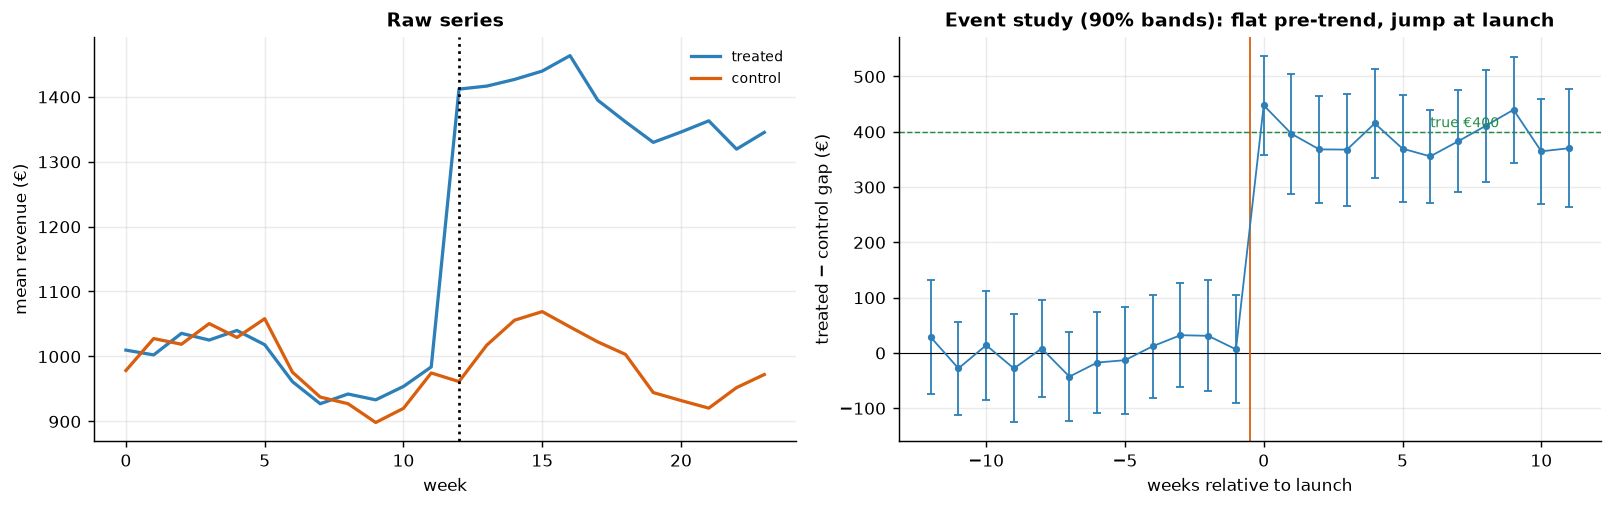

In [3]:
# event study WITH uncertainty: per-week treated−control gap ± 90% band, recentred on the pre-launch mean.
piv = df.pivot_table(index="t", columns="group", values="revenue", aggfunc="mean")
sd_ = df.pivot_table(index="t", columns="group", values="revenue", aggfunc="std")
n_  = df.pivot_table(index="t", columns="group", values="revenue", aggfunc="count")
gap = piv[1] - piv[0]
se  = np.sqrt(sd_[1]**2 / n_[1] + sd_[0]**2 / n_[0])          # SE of each week's treated−control gap
pre = gap.index < LAUNCH
gap_centered = gap - gap[pre].mean()
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
g = df.groupby(["t","group"])["revenue"].mean().unstack()
ax[0].plot(g.index, g[1], color=plots.BLUE, lw=1.8, label="treated"); ax[0].plot(g.index, g[0], color=plots.ORANGE, lw=1.8, label="control")
ax[0].axvline(LAUNCH, color="k", ls=":"); ax[0].set_xlabel("week"); ax[0].set_ylabel("mean revenue (€)"); ax[0].set_title("Raw series"); ax[0].legend(frameon=False, fontsize=8)
ax[1].errorbar(gap_centered.index - LAUNCH, gap_centered.values, yerr=1.645*se.values,
               color=plots.BLUE, marker="o", lw=1.0, ms=3, capsize=2)
ax[1].axhline(0, color="k", lw=0.6); ax[1].axvline(-0.5, color=plots.ORANGE, lw=1)
ax[1].axhline(TRUE, color=plots.GREEN, ls="--", lw=0.8); ax[1].text(6, TRUE+8, f"true €{TRUE:.0f}", fontsize=8, color=plots.GREEN)
ax[1].set_xlabel("weeks relative to launch"); ax[1].set_ylabel("treated − control gap (€)"); ax[1].set_title("Event study (90% bands): flat pre-trend, jump at launch")
fig.tight_layout()
lead_abs = gap_centered[pre].abs().mean(); lead_se = se[pre].mean()
n_out = int((gap_centered[pre].abs() > 1.645 * se[pre]).sum())
print(f"Pre-launch leads scatter around 0 within their 90% bands ({n_out} of {int(pre.sum())} exclude 0): mean |gap| "
      f"€{lead_abs:.0f}, on the order of the per-week noise SE €{lead_se:.0f} — consistent with parallel trends, not a")
print(f"pre-trend. (Centred leads average exactly 0 by construction, so it is their SPREAD vs the noise band, not a")
print(f"mean, that carries the evidence.) Post-launch gaps jump to ≈€{TRUE:.0f}.")

**How to read the event study (right panel).** This is the single most important plot in a DiD analysis.
Each dot is the treated-minus-control revenue gap in one week, relative to launch (week 0). Each dot now carries a
**90% uncertainty band**. The story we *want* to see, and do: the pre-launch dots are **flat and their bands
comfortably include zero** — that is the honest content of "parallel trends look credible" (a lead whose band
*excluded* zero would be the red flag), and the assumption the whole method rests on — and then they **jump to ≈ €400 at
launch** and stay there. A rising or falling pre-launch trend would have been a red flag that the two groups
were already diverging, and we'd have had to abandon DiD for synthetic control (notebook 07). The left panel
shows the raw series so you can see both groups riding the same seasonal wave.

## 4 · Estimate — Bayesian difference-in-differences

We now put a number and an interval on that jump. One modeling choice: we first collapse each store's
24 weekly points into a single pre-launch mean and a single post-launch mean. This is primarily the
**Bertrand–Duflo–Mullainathan (2004) serial-correlation guard** — with many periods per unit, DiD
standard errors that ignore within-unit autocorrelation are badly understated, so collapsing to two
periods (pre/post) sidesteps that. It is a modeling decision, not merely an API constraint — though
CausalPy's `DifferenceInDifferences` also happens to consume this classic **2×2 form** cleanly. The
estimate is the `group × post` interaction coefficient $\beta_3$, i.e. the DiD.


In [4]:
agg = df.groupby(["unit","group","post_treatment"])["revenue"].mean().reset_index()
agg["t"] = agg["post_treatment"].astype(int).astype(float)
# CausalPy 0.8.1's LinearRegression ships FIXED priors (beta ~ N(0,50), sigma ~ HalfNormal(1))
# scaled for O(1) data; on revenue ~ €1000 they fight the data and shrink the effect low (and
# too-narrow). We standardize revenue for the fit, then back-transform the effect to euros.
rev_mu, rev_sd = agg["revenue"].mean(), agg["revenue"].std()
agg["revenue_z"] = (agg["revenue"] - rev_mu) / rev_sd
result = est.did(agg, formula="revenue_z ~ 1 + group*post_treatment", fast=FAST)
impact = np.asarray(result.causal_impact).ravel() * rev_sd    # standardized effect -> euros
print(f"DiD effect €{impact.mean():.0f}/store/week (true €{true_effect:.0f})  ·  "
      f"90% credible interval (90% posterior probability the true effect lies inside) "
      f"[€{np.quantile(impact,0.05):.0f}, €{np.quantile(impact,0.95):.0f}]")
print(f"DiD convergence: {est.convergence_report(result.idata)["summary"]}")


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, y_hat_sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


Sampling: [beta, y_hat, y_hat_sigma]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


DiD effect €393/store/week (true €400)  ·  90% credible interval (90% posterior probability the true effect lies inside) [€274, €515]
DiD convergence: max r-hat 1.000 - min ESS 1596 - divergences 0


## 5 · Validate — 2×2 cross-check and a placebo test

Cross-check the Bayesian estimate against the hand-computed 2×2. With revenue **standardized** before
the fit (so CausalPy's default O(1)-scaled priors don't shrink a €400 effect sitting on €1000 revenue),
the two now **agree** and both land on the planted €400 with the truth inside the interval. Then
**falsify**: run DiD on the *pre-period only*, splitting it into a fake "before/after" at week 6. There
was no treatment then, so the placebo effect should be ≈ 0 — a large one would mean our design
manufactures effects.

Bayesian €393  ·  2×2 €390  ·  true €400  ·  placebo (no real effect) €17 ± SE €33 — within sampling noise of zero


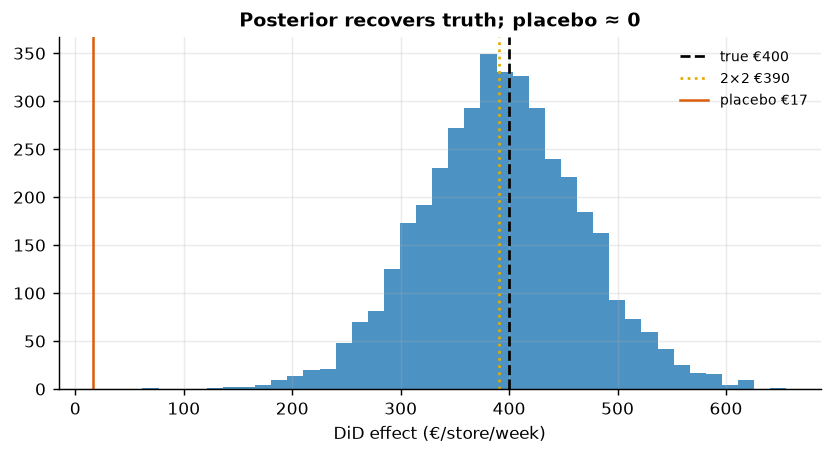

In [5]:
m = df.groupby(["group","post"])["revenue"].mean()
did_2x2 = (m[1,1]-m[1,0]) - (m[0,1]-m[0,0])
# placebo: pre-period only, fake launch at week 6
pre = df[df.t < LAUNCH].copy(); pre["fake_post"] = (pre.t >= 6).astype(int)
mp = pre.groupby(["group","fake_post"])["revenue"].mean()
placebo = (mp[1,1]-mp[1,0]) - (mp[0,1]-mp[0,0])
mp_sd = pre.groupby(["group","fake_post"])["revenue"].std()
mp_n  = pre.groupby(["group","fake_post"])["revenue"].count()
placebo_se = float(np.sqrt((mp_sd**2 / mp_n).sum()))   # SE of the placebo 2×2 = quadrature of the four cell-mean SEs
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.hist(impact, bins=40, color=plots.BLUE, alpha=0.85)
ax.axvline(true_effect, color="k", ls="--", label=f"true €{true_effect:.0f}")
ax.axvline(did_2x2, color=plots.GOLD, ls=":", label=f"2×2 €{did_2x2:.0f}")
ax.axvline(placebo, color=plots.ORANGE, lw=1.4, label=f"placebo €{placebo:.0f}")
ax.set_xlabel("DiD effect (€/store/week)"); ax.set_title("Posterior recovers truth; placebo ≈ 0"); ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
print(f"Bayesian €{impact.mean():.0f}  ·  2×2 €{did_2x2:.0f}  ·  true €{true_effect:.0f}  ·  "
      f"placebo (no real effect) €{placebo:.0f} ± SE €{placebo_se:.0f} — within sampling noise of zero")

### 5b · Recovery across many seeds — unbiased *and* calibrated?

A single sample can land a little off; the real test is whether the estimator is **centred on the truth over repeated samples** and whether its 90% interval **covers** the truth at the stated rate. We refit on many fresh samples (a small fast fit each; their sampler chatter is silenced below) and check both. Coverage can fail in **both** directions — an interval can be too *narrow* (overconfident) or too *wide* (conservative) — so beside counting hits we also compare the interval's width against the true seed-to-seed scatter.

DiD across 20 seeds: mean €403 (true €400)  bias +3  sd €11  ·  90% interval covers truth in 20/20 seeds.
But read 20/20 carefully: the headline interval's ±€121 half-width is ~11× the true seed-to-seed scatter (sd €11) — OVER-coverage, not perfect calibration. The 2×2 collapse leaves between-store baseline spread in the residual, so the interval is honest but conservative; downstream bounds (the break-even running cost, the stress-table probabilities) inherit that width — cautious, not sharp. (Store fixed effects / within-store differencing would tighten it.)


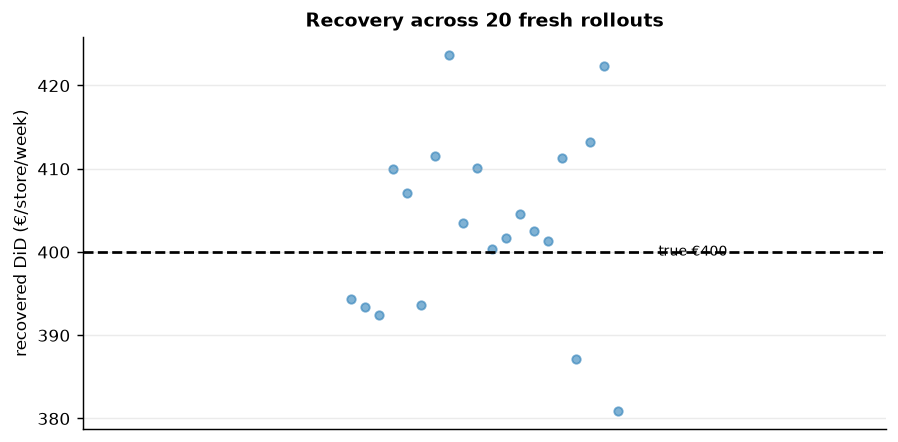

In [6]:
# --- Recovery across many seeds: does the DiD recover €400 and cover it? ---
NSEED = 8 if FAST else 20
import logging
_pml = logging.getLogger("pymc"); _pml_lvl = _pml.level   # silence the per-seed refits' sampler chatter
_pml.setLevel(logging.CRITICAL + 1)                       # (disclosed above; the same trick pymc's own
# _quiet_logging uses — the low-ESS notice is logged at ERROR level); restored at the end of the cell
pts = []; cov = 0
for sd in range(NSEED):
    d, te = dgp.did_rollout(n_stores=40, n_weeks=24, launch_week=LAUNCH, seed=100 + sd)
    ag = d.groupby(["unit", "group", "post_treatment"])["revenue"].mean().reset_index()
    ag["t"] = ag["post_treatment"].astype(int).astype(float)
    sv = ag["revenue"].std(); ag["revenue_z"] = (ag["revenue"] - ag["revenue"].mean()) / sv
    r = est.did(ag, formula="revenue_z ~ 1 + group*post_treatment", fast=True)
    im = np.asarray(r.causal_impact).ravel() * sv
    pts.append(im.mean()); lo, hi = np.quantile(im, [.05, .95]); cov += int(lo <= te <= hi)
pts = np.array(pts)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.scatter(np.linspace(-0.2, 0.2, NSEED), pts, s=22, color=plots.BLUE, alpha=0.6)
ax.axhline(true_effect, color="k", ls="--"); ax.text(0.26, true_effect, f"true €{true_effect:.0f}", fontsize=8, va="center")
ax.set_xticks([]); ax.set_xlim(-0.6, 0.6); ax.set_ylabel("recovered DiD (€/store/week)")
ax.set_title(f"Recovery across {NSEED} fresh rollouts"); fig.tight_layout()
print(f"DiD across {NSEED} seeds: mean €{pts.mean():.0f} (true €{true_effect:.0f})  bias {pts.mean()-true_effect:+.0f}  "
      f"sd €{pts.std():.0f}  ·  90% interval covers truth in {cov}/{NSEED} seeds.")
half = float(np.quantile(impact, 0.95) - np.quantile(impact, 0.05)) / 2
print(f"But read {cov}/{NSEED} carefully: the headline interval's ±€{half:.0f} half-width is "
      f"~{half/pts.std():.0f}× the true seed-to-seed scatter (sd €{pts.std():.0f}) — OVER-coverage, not perfect "
      f"calibration. The 2×2 collapse leaves between-store baseline spread in the residual, so the interval is "
      f"honest but conservative; downstream bounds (the break-even running cost, the stress-table probabilities) "
      f"inherit that width — cautious, not sharp. (Store fixed effects / within-store differencing would tighten it.)")
_pml.setLevel(_pml_lvl)

## 6 · Decide, in euros — the rollout case

Under parallel trends the DiD number is the **ATT — the effect on the pilot stores.** Rolling the app out to
all 500 assumes the other 480 respond the same way, which chains rarely guarantee (pilot sites aren't picked
at random). So alongside the headline projection we **stress it two ways**: a **transfer discount** (what if
the non-pilot stores realise only 75% or 50% of the pilot lift?) and a **cost sweep** (how high can the app's
running cost climb before the call flips?). The table below is P(app pays) across both — robust at full
transfer, but a *pilot-further* call under aggressive discounting and higher running costs. (The €120 running cost is an illustrative all-in figure — licences + operations per store-week; one-time build/rollout capex is deliberately outside the per-week economics.)

In [7]:
N_STORES, WEEKS, APP_COST = 500, 52, 120.0   # APP_COST: illustrative all-in running cost (licence+ops)/store-week
                                             # — swap in your vendor quote; one-time build capex is out of scope
net = impact - APP_COST
annual = net * N_STORES * WEEKS
p_worth = (net > 0).mean()
print(f"Base case (APP_COST €{APP_COST:.0f}, full pilot lift across {N_STORES} stores):")
print(f"  net €{net.mean():.0f}/store/week  ·  annual value €{annual.mean():,.0f} "
      f"[90% €{np.quantile(annual,0.05):,.0f}, €{np.quantile(annual,0.95):,.0f}]  ·  P(app pays) {p_worth:.2f} → "
      + ("ROLL OUT" if p_worth > 0.9 else "pilot further"))
be95 = np.quantile(impact, 0.05)
print(f"  break-even: the app clears its cost with 95% posterior probability while the running cost stays "
      f"below ~€{be95:.0f}/store/week.")

# Stress the roll-out two ways: (a) TRANSFER discount — the 480 non-pilot stores may realize less than the
# pilot ATT; (b) a COST sweep — how high can the running cost climb before the roll-out call flips?
transfers = [(1.00, "100% (as pilot)"), (0.75, "75%"), (0.50, "50%")]
costgrid = [80, 120, 200, 300]
print("\nP(app pays) by transfer share (rows) and running cost in €/store/week (cols):")
print("  transfer \\ cost" + "".join(f"{c:>7}" for c in costgrid))
for tr, lab in transfers:
    eff = impact * tr
    print(f"  {lab:<15}" + "".join(f"{(eff > c).mean():>7.2f}" for c in costgrid))
print("\nMost the roll-out can pay per store/week and still clear cost at 90% posterior confidence:")
for tr, lab in transfers:
    print(f"  at {lab:<16} up to ~€{np.quantile(impact * tr, 0.10):.0f}")

Base case (APP_COST €120, full pilot lift across 500 stores):
  net €273/store/week  ·  annual value €7,097,941 [90% €3,993,808, €10,272,351]  ·  P(app pays) 1.00 → ROLL OUT
  break-even: the app clears its cost with 95% posterior probability while the running cost stays below ~€274/store/week.

P(app pays) by transfer share (rows) and running cost in €/store/week (cols):
  transfer \ cost     80    120    200    300
  100% (as pilot)   1.00   1.00   0.99   0.90
  75%               1.00   1.00   0.96   0.46
  50%               1.00   0.98   0.46   0.00

Most the roll-out can pay per store/week and still clear cost at 90% posterior confidence:
  at 100% (as pilot)  up to ~€300
  at 75%              up to ~€225
  at 50%              up to ~€150


**Read-out.** At face value the base case is emphatic: ≈ €273/store/week of net value over the
€120 running cost, ≈ €7.1M of annual value across the 500-store chain, P(app pays) ≈ 1.00 →
**ROLL OUT**. The stress table is where the real decision lives, and it splits along one axis:
reading *across* a row, the call barely moves with the running cost while the transfer assumption
holds; reading *down* a column, it degrades fast as the assumed transfer falls — at 50% transfer
the €200 cost cell is a coin flip (0.46) and €300 is a clear no (0.00). Since pilot stores are
rarely representative of the chain, the honest headline is the last block: the rollout can pay
**up to ≈ €300/store/week if the whole chain responds like the pilot, but only ≈ €150 if half the
lift transfers** — that range, not the base-case €7.1M, is the number to hold against a vendor
quote. If the quote lands inside it, the cheap de-risking move is a second pilot wave in
deliberately *non*-pilot-like stores to measure the transfer share directly.

## 7 · Caveats — and the staggered-adoption trap, demonstrated

**Parallel trends is the whole ballgame** and untestable post-launch; a diverging pre-trend kills the
design (use synthetic control, nb 07). **No spillover** between nearby stores. But the subtlest trap is
**staggered adoption**: when units adopt at *different* times, naive two-way fixed-effects DiD uses
already-treated units as controls ("forbidden comparisons") and can put **negative weights** on some
effects (Goodman-Bacon), biasing the estimate even when every true effect is positive. We show it live:


Naive TWFE €177 vs true average post-treatment effect €400 — bias -223. Use Callaway–Sant'Anna / Sun–Abraham for staggered rollouts.


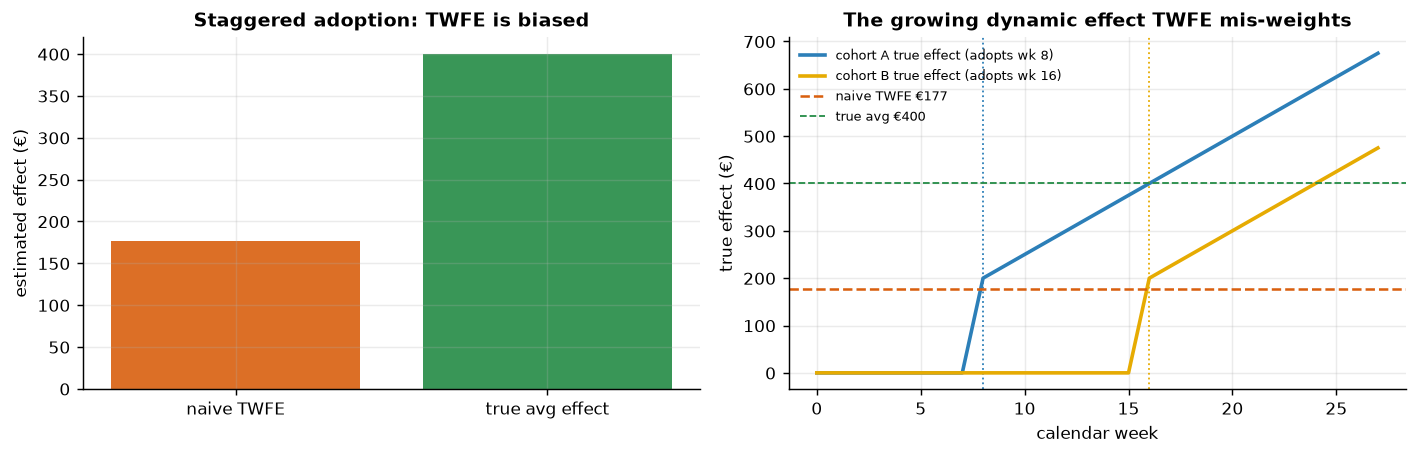

In [8]:
# staggered rollout: cohort A treated at week 8, cohort B at week 16, with a GROWING true effect
rng = np.random.default_rng(1); NS, NW = 60, 28
rows = []
for s in range(NS):
    cohort = "A" if s < NS//2 else "B"; g = 8 if cohort=="A" else 16
    base = rng.normal(1000, 120); season = 60*np.sin(2*np.pi*np.arange(NW)/12)
    # dynamic effect that GROWS after adoption (this is what breaks naive TWFE)
    te = np.where(np.arange(NW) >= g, 200 + 25*(np.arange(NW)-g), 0.0)
    rev = base + season + te + rng.normal(0, 60, NW)
    for t in range(NW):
        rows.append({"unit": s, "cohort": cohort, "t": t, "post": int(t>=g), "rev": rev[t], "true_te": te[t]})
sd = pd.DataFrame(rows)
# naive TWFE (single post dummy) vs the true average post-treatment effect
Xd = pd.get_dummies(sd["unit"], prefix="u").astype(float); Xt = pd.get_dummies(sd["t"], prefix="t").astype(float)
D = np.column_stack([np.ones(len(sd)), sd["post"].values, Xd.values[:,1:], Xt.values[:,1:]])
twfe = np.linalg.lstsq(D, sd["rev"].values, rcond=None)[0][1]
true_avg = sd.loc[sd.post==1, "true_te"].mean()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar(["naive TWFE","true avg effect"], [twfe, true_avg], color=[plots.ORANGE, plots.GREEN], alpha=0.9)
ax[0].set_ylabel("estimated effect (€)"); ax[0].set_title("Staggered adoption: TWFE is biased")
# WHY it's biased: the true effect GROWS after each cohort adopts (weeks 8 and 16), so collapsing it
# to one post dummy — while using already-treated cohort A as a control for B — badly mis-weights it.
for _coh, _col in [("A", plots.BLUE), ("B", plots.GOLD)]:
    _g = 8 if _coh == "A" else 16
    _te = sd[sd.cohort == _coh].groupby("t")["true_te"].mean()
    ax[1].plot(_te.index, _te.values, color=_col, lw=2, label=f"cohort {_coh} true effect (adopts wk {_g})")
    ax[1].axvline(_g, color=_col, ls=":", lw=1)
ax[1].axhline(twfe, color=plots.ORANGE, ls="--", lw=1.4, label=f"naive TWFE €{twfe:.0f}")
ax[1].axhline(true_avg, color=plots.GREEN, ls="--", lw=1.0, label=f"true avg €{true_avg:.0f}")
ax[1].set_xlabel("calendar week"); ax[1].set_ylabel("true effect (€)")
ax[1].set_title("The growing dynamic effect TWFE mis-weights"); ax[1].legend(frameon=False, fontsize=7)
fig.tight_layout()
print(f"Naive TWFE €{twfe:.0f} vs true average post-treatment effect €{true_avg:.0f} — "
      f"bias {twfe-true_avg:+.0f}. Use Callaway–Sant'Anna / Sun–Abraham for staggered rollouts.")